In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from idun_guardian_sdk import GuardianClient, FileTypes
from scipy import signal

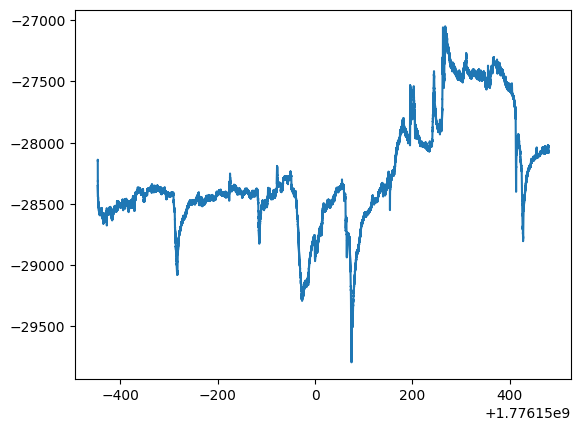

In [2]:
df = pd.read_csv("../data/eeg_Test3Simon.csv")

plt.figure()
plt.plot(df["timestamp"], df["ch1"])
plt.show()


In [3]:
fs = 250.0
sig = df["ch1"].to_numpy()

# Highpass wie gehabt (oder gleich bandpass 1-40 Hz)
sos_hp = signal.iirdesign(wp=1, ws=0.5, gpass=1, gstop=40, ftype="butter", output="sos", fs=fs)

# zero-phase
sig_filt = signal.sosfiltfilt(sos_hp, sig)


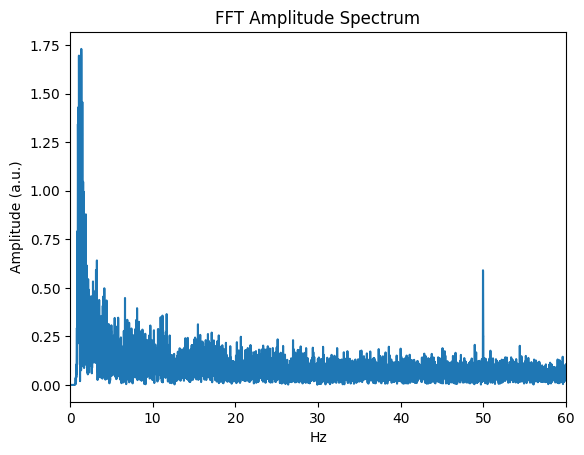

In [4]:
fs = 250.0
y = sig_filt

N = len(y)
window = signal.windows.hann(N, sym=False)
yw = y * window

Y = np.fft.rfft(yw)
f = np.fft.rfftfreq(N, d=1/fs)

# Amplitudenspektrum (ungefähr, window-korrigiert)
amp = (2.0 / np.sum(window)) * np.abs(Y)

plt.figure()
plt.plot(f, amp)
plt.xlim(0, 60)   # EEG meist 0-60 interessant
plt.xlabel("Hz")
plt.ylabel("Amplitude (a.u.)")
plt.title("FFT Amplitude Spectrum")
plt.show()


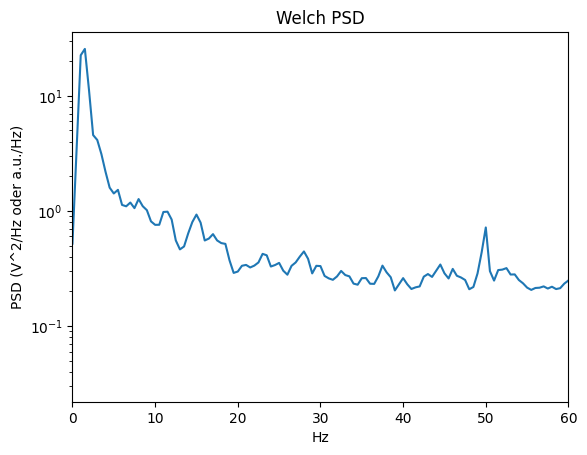

In [5]:
fs = 250.0
y = sig_filt

f, Pxx = signal.welch(
    y,
    fs=fs,
    window="hann",
    nperseg=fs*2,      # 2 Sekunden Fenster
    noverlap=fs,       # 50% overlap
    detrend="constant",
    scaling="density"
)

plt.figure()
plt.semilogy(f, Pxx)
plt.xlim(0, 60)
plt.xlabel("Hz")
plt.ylabel("PSD (V^2/Hz oder a.u./Hz)")
plt.title("Welch PSD")
plt.show()


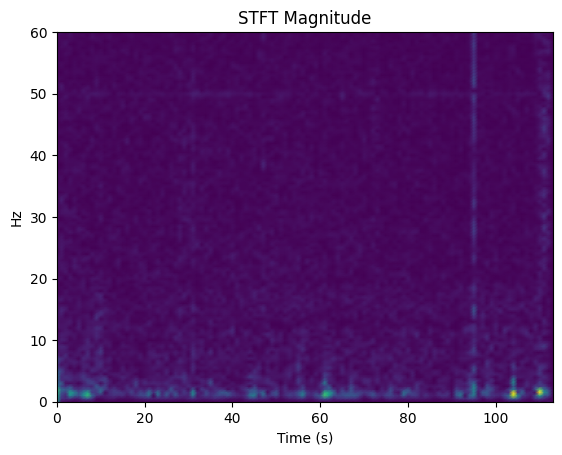

In [6]:
fs = 250.0
f, t, Zxx = signal.stft(sig_filt, fs=fs, window="hann", nperseg=fs*2, noverlap=fs)

plt.figure()
plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylim(0, 60)
plt.xlabel("Time (s)")
plt.ylabel("Hz")
plt.title("STFT Magnitude")
plt.show()


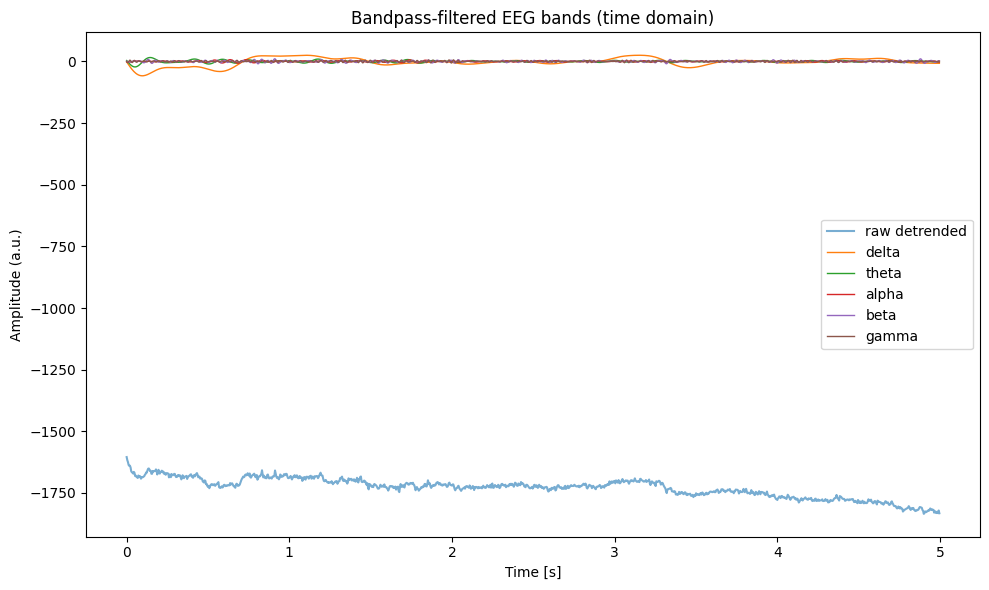

RMS per band:
delta: 10.2827
theta: 2.23924
alpha: 1.82479
 beta: 2.59333
gamma: 1.87259


In [7]:
fs = 250.0
t = df["timestamp"].to_numpy()
x = df["ch1"].to_numpy()

# DC raus (wichtig, sonst dominiert 0 Hz)
x = signal.detrend(x, type="constant")

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta" : (13, 30),
    "gamma": (30, 45),   # bei 250 Hz: Nyquist 125, aber Gamma >~45 oft EMG/Noise bei Consumer-EEG
}

band_signals = {}

for name, (lo, hi) in bands.items():
    sos = signal.butter(N=4, Wn=[lo, hi], btype="bandpass", fs=fs, output="sos")
    band_signals[name] = signal.sosfiltfilt(sos, x)

# --- Plot: erste 5 Sekunden (oder weniger, falls Signal kürzer)
duration_s = 5
n = min(len(x), int(duration_s * fs))
tt = (t[:n] - t[0])  # relative Zeit in s

plt.figure(figsize=(10, 6))
plt.plot(tt, x[:n], label="raw detrended", alpha=0.6)
for name in ["delta","theta","alpha","beta","gamma"]:
    plt.plot(tt, band_signals[name][:n], label=name, linewidth=1)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude (a.u.)")
plt.title("Bandpass-filtered EEG bands (time domain)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Option: RMS als grobes Maß für "Bandstärke"
def rms(y):
    return np.sqrt(np.mean(y**2))

print("RMS per band:")
for name in bands:
    print(f"{name:>5}: {rms(band_signals[name]):.6g}")


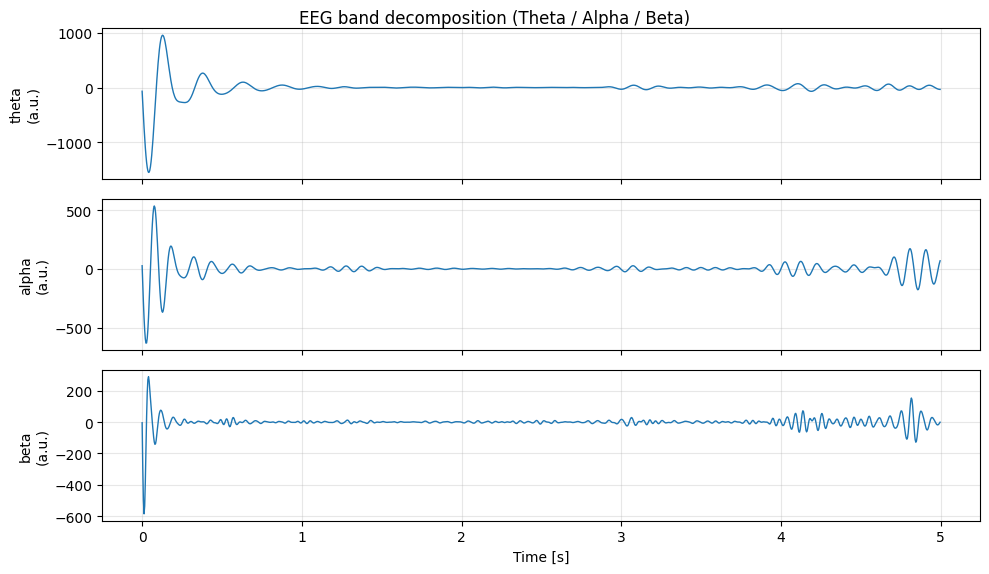

In [8]:
df = pd.read_csv("../data/eeg_1770648754084.csv")

fs = 250.0
t = df["timestamp"].to_numpy()
x = df["ch1"].to_numpy()

# DC raus
x = signal.detrend(x, type="constant")

# Nur relevante EEG-Bänder
bands = {
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta" : (13, 30),
}

band_signals = {}

for name, (lo, hi) in bands.items():
    sos = signal.butter(
        N=4,
        Wn=[lo, hi],
        btype="bandpass",
        fs=fs,
        output="sos"
    )
    band_signals[name] = signal.sosfiltfilt(sos, x)

# --- Plot: 5 Sekunden, getrennte Subplots
duration_s = 5
n = min(len(x), int(duration_s * fs))
tt = t[:n] - t[0]

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, name in zip(axes, ["theta", "alpha", "beta"]):
    ax.plot(tt, band_signals[name][:n], linewidth=1)
    ax.set_ylabel(f"{name}\n(a.u.)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("EEG band decomposition (Theta / Alpha / Beta)", y=0.95)

plt.tight_layout()
plt.show()